In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../utils"))  # repo utils/ (vendored sweep + shared helpers)
import os
from sweep import sweep_load as sl
from sweep import raster
import numpy as np
import numpy.matlib
import matplotlib.pyplot as plt
from matplotlib import colors
from cycler import cycler
%matplotlib inline

In [2]:
file_path = '../data/raw_sweeps'

In [3]:
rc_params = {
    'xtick.direction': 'in',
    'xtick.top': True,
    'ytick.direction': 'in',
    'ytick.right': True,
    'axes.edgecolor': 'k',
    'axes.labelcolor': 'k',
    'xtick.color': 'k',
    'ytick.color': 'k',
    'figure.facecolor': 'white',
    'font.size': 16,
    'axes.labelsize': 16,
    'legend.title_fontsize': 14,
    'axes.linewidth': 1.5,
    'xtick.major.size': 5,
    'xtick.major.width': 1.5,
    'xtick.minor.size': 2.5,
    'xtick.minor.width': 1.5,
    'ytick.major.size': 5,
    'ytick.major.width': 1.5,
    'ytick.minor.size': 2.5,
    'ytick.minor.width': 1.5,
    'lines.linewidth': 2.5,
    'figure.figsize': [3*1.618, 3]
}
plt.rcParams.update(rc_params)

In [4]:
h = 6.626E-34
e = 1.6002E-19
phi0 = h/e
dbg = 40.5
dtg = 26
ep = 3
Rq = h/e**2


In [5]:
def calculate_gate_voltages(n, D, dtg=16, dbg=25.5):
    # Calculate electron density n from nu
    ep = 3   
    conversion_factor = 5.52634936
    # Set up system of equations based on original expressions for n and D
    # Rearrange these to solve for Vbg and Vtg
    Vtg = (n / (ep * conversion_factor) + 2* D/ep) * dtg/2
    Vbg = dbg*(n / (ep * conversion_factor) - Vtg/dtg)

    return Vtg, Vbg

def calculate_n_D(Vtg, Vbg, dtg=16, dbg=25.5):
    ep = 3
    n = (Vbg/dbg + Vtg/dtg)*ep*5.52634936 # in units of cm^-2 assuming BN dielectric = 3
    D = 0.5*ep*(Vtg/dtg - Vbg/dbg)
    
    return n, D

def comment_to_gates(comment, delim=':'):
    parts = comment.split(delim)
    key_part = parts[0].strip()
    values_part = parts[-1].strip()
    values = values_part.strip('()').split(',')
    Vtg = float(values[0].strip())
    Vbg = float(values[1].strip())
    return Vtg, Vbg
    

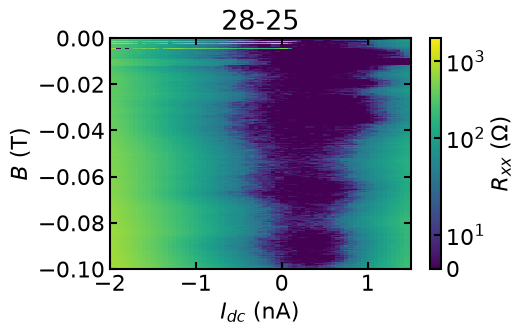

In [6]:
files= [1400]

contact_pairs = {
    'curr': {'indices': [], 'norm': colors.Normalize(vmin=0.8, vmax=1), 'cmap': 'viridis', 'label': r'$I/I_0$'},
    'long1': {'indices': [2, ], 'norm': colors.SymLogNorm(linthresh=25, vmin=0, vmax=0.2E4), 'cmap': 'viridis', 'label': r'$R_{xx}$ ($\Omega$)'},
    'hall1': {'indices': [], 'norm': colors.SymLogNorm(linthresh=50, vmin=1E3, vmax=1E5), 'cmap': 'viridis', 'label': r'$R_{yx}$ ($\Omega$)'},
}


gates = True
for pair, options in contact_pairs.items():
    indices = options['indices']
    norm = options.get('norm', None)
    cmap = options['cmap']
    label = options['label']
    vmin = options.get('vmin', None)
    vmax = options.get('vmax', None)
    for ind in indices:
        fig, ax = plt.subplots(figsize=(3*1.618, 3))
        for file in files:
            # load in the new data
            data = sl.pload(file_path, file)
            mc_0 = data['measurement_config']
            md = sl.load_meta(file_path, file)
            xs = data['xs']*10
            ys = data['ys']
            phase = data[f'sr830_{ind}_P']
    
            if pair=='curr':
                I = data['sr830_4_X']
                zs= I/(md['comments'][1]['I_ac']*1E-9)
            else:
                I = data['sr830_4_X']
                Vxx = data[f'sr830_{ind}_X']
                zs = Vxx / I
                
                mask = np.abs(I) < 0.0 * np.nanmax(np.abs(I))
                zs = np.ma.array(zs, mask=mask)
    

            
    
            plot = ax.pcolormesh(xs, ys, zs, norm=norm, cmap=cmap, rasterized=True, lw=0)
            

        plt.colorbar(plot, ax=ax, label=label)
        ax.set_title(mc_0[f'sr830_{ind}'])

        
        ax.set_ylabel(r'$B$ (T)')
        ax.set_xlabel(r'$I_{dc}$ (nA)')
        ax.set_ylim(-0.1, 0.0)
        ax.set_xlim(-2, 1.5)

        yvals = [10, 16, 22]
        # for y in yvals:
            # ax.axhline(-y/1000, color='r', ls='--', lw=1)
        plt.savefig(os.path.join(f'rmg19_deep_fran_secondattempt_{ind}_full.pdf'), dpi=300, bbox_inches='tight')





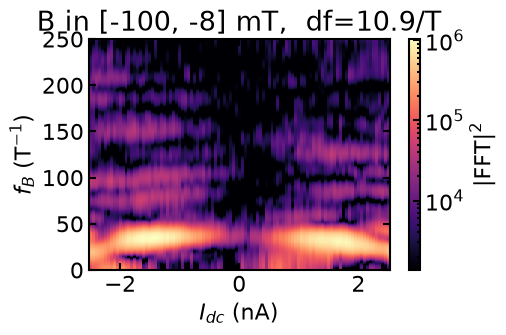

In [7]:
# ---- FFT vs B at fixed Idc, one sign of field (|FFT|^2 color map) ----
import utils as u

ind = 2                   # long1 contact pair, matches the panel above
BLO, BHI = -0.1, -0.008   # field window (T): one sign, away from the central switching spikes
CUTOFF = 12               # Butterworth high-pass cutoff (cycles/T) -> removes slow MR background
ORDER = 2
PADDING = 10               # zero-padding factor (display interpolation only)

data = sl.pload(file_path, 1400)
xs = data['xs'] * 10                 # Idc (nA)
ys = data['ys']                      # B (T)
zs = data[f'sr830_{ind}_X'] / data['sr830_4_X']   # Rxx(B, Idc)

# sort B ascending (acquired descending), restrict to the one-sign window.
# raw B grid is already uniform (dB = 5e-4 T) -> no interpolation needed.
order = np.argsort(ys)
B = ys[order]
R = zs[order, :]
m = (B >= BLO) & (B <= BHI)
B, R = B[m], R[m, :]
N = R.shape[0]
dB = np.abs(np.mean(np.diff(B)))

# per-Idc: Butterworth high-pass detrend (utils_v2) -> Hanning -> zero-pad -> rfft over B
win = np.hanning(N)
cols = []
for j in range(R.shape[1]):
    hp, _ = u.detrend_butterworth(B, R[:, j], cutoff=CUTOFF, order=ORDER)
    yp = np.pad(hp * win, (N * PADDING, N * PADDING))
    cols.append(np.abs(np.fft.rfft(yp))**2)
power = np.array(cols).T                                  # (Nfreq, NIdc)
freqs = np.fft.rfftfreq((2 * PADDING + 1) * N, d=dB)      # cycles per T

fig, ax = plt.subplots(figsize=(3*1.618, 3))
pmin = np.percentile(power[power > 0], 60)
im = ax.pcolormesh(xs, freqs, power,
                   norm=colors.LogNorm(vmin=pmin, vmax=power.max()),
                   cmap='magma', rasterized=True, lw=0)
plt.colorbar(im, ax=ax, label=r'$|\mathrm{FFT}|^2$')
ax.set_ylim(0, 250)                  # period >= 4 mT; raise to see harmonics
ax.set_xlabel(r'$I_{dc}$ (nA)')
ax.set_ylabel(r'$f_B$ (T$^{-1}$)')
ax.set_title(f"B in [{BLO*1e3:.0f}, {BHI*1e3:.0f}] mT,  df={1/(B[-1]-B[0]):.1f}/T")
plt.savefig(os.path.join(f'rmg19_fran_fftB_onesign_{ind}.pdf'), dpi=300, bbox_inches='tight')


peak: 36.2 T^-1  ->  period 27.6 mT   (Idc = -1.00 nA)


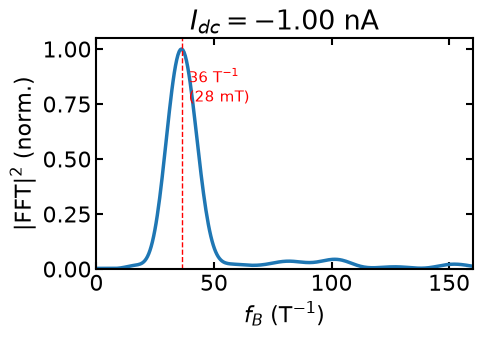

In [8]:
# ---- 1D spectrum of the cleanest trace (reuses power/freqs from the cell above) ----
IDC_PICK = -1.0                 # nA; column with the cleanest single-peak FFT
jpick = np.abs(xs - IDC_PICK).argmin()
P1 = power[:, jpick]
P1n = P1 / P1.max()

sel = (freqs > 5) & (freqs < 60)        # search the oscillation band for the peak
fpk = freqs[sel][P1[sel].argmax()]

fig, ax = plt.subplots(figsize=(3*1.618, 3))
ax.plot(freqs, P1n)
ax.axvline(fpk, color='r', ls='--', lw=1)
ax.text(fpk + 3, 0.92, f'{fpk:.0f} T$^{{-1}}$\n({1e3/fpk:.0f} mT)',
        color='r', fontsize=11, va='top')
ax.set_xlim(0, 160)
ax.set_ylim(bottom=0)
ax.set_xlabel(r'$f_B$ (T$^{-1}$)')
ax.set_ylabel(r'$|\mathrm{FFT}|^2$ (norm.)')
ax.set_title(rf'$I_{{dc}} = {xs[jpick]:.2f}$ nA')
plt.savefig(os.path.join(f'rmg19_fran_fftB_1d_{ind}.pdf'), dpi=300, bbox_inches='tight')
print(f'peak: {fpk:.1f} T^-1  ->  period {1e3/fpk:.1f} mT   (Idc = {xs[jpick]:.2f} nA)')


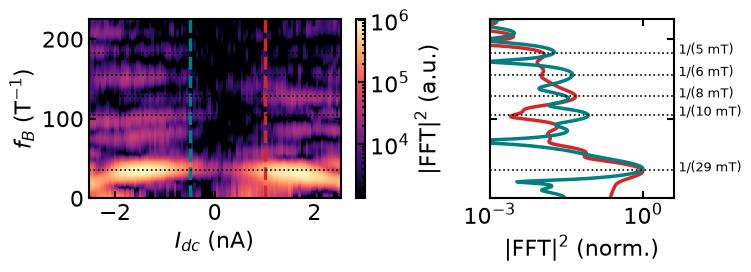

In [9]:
# ---- Side by side: |FFT|^2 colormap + 1D linecuts (shared f_B axis) ----
IDC_PICKS   = [1.0, -0.50]            # nA; linecut biases (add more as desired)
LINE_COLORS = ['tab:red', 'teal']      # color per linecut (cycles if fewer than picks)

FMAX = 225                            # T^-1 display window for both panels
fig, (axL, axR) = plt.subplots(1, 2, figsize=(2.6*3, 3), sharey=True,
                               gridspec_kw={'width_ratios': [2.4, 1.4]})

# left: |FFT|^2 colormap
pmin = np.percentile(power[power > 0], 60)
im = axL.pcolormesh(xs, freqs, power,
                    norm=colors.LogNorm(vmin=pmin, vmax=power.max()),
                    cmap='magma', rasterized=True, lw=0)
axL.set_ylim(0, FMAX)
axL.set_xlabel(r'$I_{dc}$ (nA)')
axL.set_ylabel(r'$f_B$ (T$^{-1}$)')
plt.colorbar(im, ax=axL, label=r'$|\mathrm{FFT}|^2$ (a.u.)')

# right: one 1D spectrum per bias, rotated so f_B is shared with the map
sel = (freqs > 5) & (freqs < 60)
for k, idc in enumerate(IDC_PICKS):
    c = LINE_COLORS[k % len(LINE_COLORS)]
    j = np.abs(xs - idc).argmin()
    P1n = power[:, j] / power[:, j].max()
    fpk = freqs[sel][power[:, j][sel].argmax()]
    axL.axvline(xs[j], color=c, ls='--', lw=2.5)                  # mark bias on map
    axR.plot(P1n, freqs, color=c,
             label=rf'{xs[j]:.2f} nA  ({fpk:.0f} T$^{{-1}}$, {1e3/fpk:.0f} mT)')

# annotated horizontal line(s) at the dominant frequency(ies)
ANNOT_FREQS = [35, 105, 128, 155, 183]            # T^-1; add a second value to mark another tone
for f0 in ANNOT_FREQS:
    for a in (axL, axR):
        a.axhline(f0, color='k', ls=':', lw=1.2)
    axR.text(5, f0 - 5, rf'1/({1e3/f0:.0f} mT)',
             fontsize=9, va='bottom', ha='left')

axR.set_xscale('log')
axR.set_xlim(1e-3, 4)
axR.set_xlabel(r'$|\mathrm{FFT}|^2$ (norm.)')
# axR.legend(fontsize=7, loc='upper left')

plt.tight_layout()
plt.savefig(os.path.join(f'rmg19_fran_fftB_sidebyside_{ind}.pdf'),
            dpi=300, bbox_inches='tight')


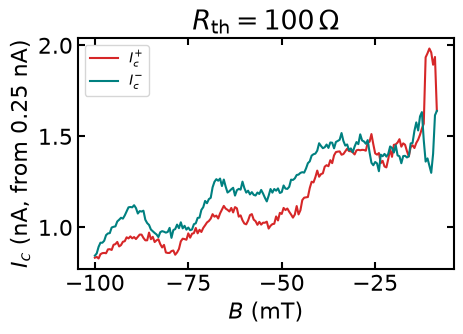

In [10]:
# ---- Critical current Ic+/- via thresholding (real-space oscillation) ----
# Idc is asymmetric about ~0.25 nA (the SC center is offset), so measure Ic from there.
R_TH = 100.0      # ohm; switching threshold
I0   = 0.25       # nA; SC center

# reuse the cell-9 field window (BLO, BHI) and contact (ind)
_d  = sl.pload(file_path, 1400)
_I  = _d['xs'] * 10                            # Idc (nA)
_ys = _d['ys']
_R  = _d[f'sr830_{ind}_X'] / _d['sr830_4_X']
_o  = np.argsort(_ys); _B = _ys[_o]; _R = _R[_o, :]
_m  = (_B >= BLO) & (_B <= BHI)
Bic, Ric = _B[_m], _R[_m, :]

def _edge(Iax, r, rth, direction):
    """March outward from I0 toward +/- bias; return interpolated Idc where R first crosses rth."""
    j0 = np.abs(Iax - I0).argmin()
    rng = range(j0 + 1, len(Iax)) if direction > 0 else range(j0 - 1, -1, -1)
    prev = j0
    for k in rng:
        if r[k] >= rth:
            if r[k] == r[prev]:
                return Iax[k]
            t = (rth - r[prev]) / (r[k] - r[prev])
            return Iax[prev] + t * (Iax[k] - Iax[prev])
        prev = k
    return np.nan

Icp = np.array([_edge(_I, Ric[i], R_TH, +1) - I0 for i in range(len(Bic))])   # + side
Icm = np.array([I0 - _edge(_I, Ric[i], R_TH, -1) for i in range(len(Bic))])   # - side

fig, ax = plt.subplots(figsize=(3*1.618, 3))
ax.plot(Bic*1e3, Icp, color='tab:red', lw=1.5, label=r'$I_c^{+}$')
ax.plot(Bic*1e3, Icm, color='teal',    lw=1.5, label=r'$I_c^{-}$')
ax.set_xlabel(r'$B$ (mT)')
ax.set_ylabel(rf'$I_c$ (nA, from {I0:.2f} nA)')
ax.set_title(rf'$R_{{\rm th}}={R_TH:.0f}\,\Omega$')
ax.legend(fontsize=10)
plt.savefig(os.path.join(f'rmg19_fran_Ic_{ind}.pdf'), dpi=300, bbox_inches='tight')


fixed center I0 = 0.182 nA (median band midpoint)


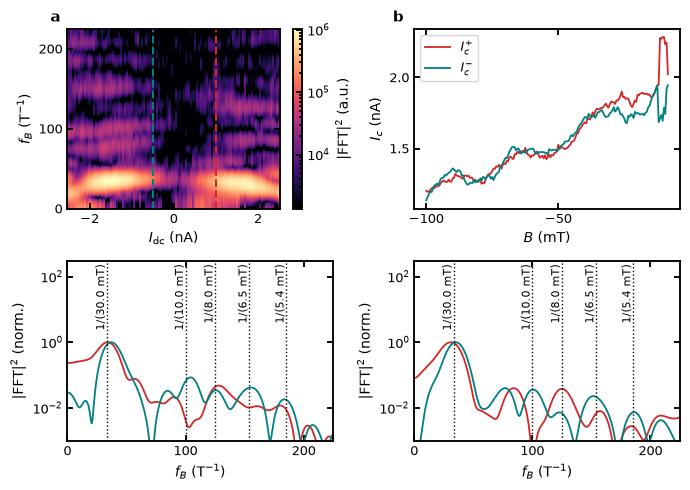

In [11]:
# ---- Four-panel summary figure (publication-ready) ----
import utils as u
RTH         = 200.0            # ohm; Ic switching threshold
FMAX        = 225             # T^-1; display window for spectra / colormap f-axis
ANNOT_FREQS = [1/0.030, 1/0.010, 1/.008, 1/.0065, 1/.0054]   # T^-1; tones to mark on every f_B axis
IDC_PICKS   = [1.0, -0.50]    # nA; line-cut biases
LINE_COLORS = ['tab:red', 'teal']

# rcParams shared with linecut_fft_grid.py (applied locally via rc_context)
_scale = 0.9
GRID_RC = {
    'font.family': 'sans-serif',
    'axes.labelsize': 10, 'axes.titlesize': 10, 'font.size': 10,
    'legend.title_fontsize': 9, 'legend.fontsize': 9,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'xtick.direction': 'in', 'xtick.top': True,
    'ytick.direction': 'in', 'ytick.right': True,
    'xtick.major.size': 5*_scale, 'xtick.major.width': 1.5*_scale,
    'xtick.minor.size': 2.5*_scale, 'xtick.minor.width': 1.5*_scale,
    'ytick.major.size': 5*_scale, 'ytick.major.width': 1.5*_scale,
    'ytick.minor.size': 2.5*_scale, 'ytick.minor.width': 1.5*_scale,
    'axes.linewidth': 1.5*_scale, 'lines.linewidth': 2.5*_scale,
}

# --- load + window (inherits ind, BLO, BHI, CUTOFF, ORDER, PADDING from above) ---
_d  = sl.pload(file_path, 1400)
Idc = _d['xs'] * 10
_ys = _d['ys']
_R  = _d[f'sr830_{ind}_X'] / _d['sr830_4_X']
_o  = np.argsort(_ys); _B = _ys[_o]; _R = _R[_o, :]
_m  = (_B >= BLO) & (_B <= BHI)
Bw, Rw = _B[_m], _R[_m, :]
Nb, dBw = len(Bw), np.abs(np.mean(np.diff(Bw)))

# --- B-domain FFT (Butterworth high-pass + Hanning + zero-pad); shared freq axis ---
def bspec(y):
    hp, _ = u.detrend_butterworth(Bw, y, cutoff=CUTOFF, order=ORDER)
    yp = np.pad(hp * np.hanning(Nb), (Nb * PADDING, Nb * PADDING))
    return np.abs(np.fft.rfft(yp))**2
fB = np.fft.rfftfreq((2 * PADDING + 1) * Nb, d=dBw)
powmap = np.array([bspec(Rw[:, j]) for j in range(Rw.shape[1])]).T   # (Nfreq, NIdc)

# --- Ic extraction with a FIXED center = median band midpoint ---
def band_edges(Iax, r, rth):
    below = r < rth; jmin = np.argmin(r)
    if not below[jmin]:
        return np.nan, np.nan
    lo = jmin
    while lo - 1 >= 0 and below[lo - 1]: lo -= 1
    hi = jmin
    while hi + 1 < len(r) and below[hi + 1]: hi += 1
    Ilo = Iax[lo] if lo == 0 else Iax[lo-1] + (rth-r[lo-1])/(r[lo]-r[lo-1])*(Iax[lo]-Iax[lo-1])
    Ihi = Iax[hi] if hi == len(r)-1 else Iax[hi] + (rth-r[hi])/(r[hi+1]-r[hi])*(Iax[hi+1]-Iax[hi])
    return Ilo, Ihi
edges = np.array([band_edges(Idc, Rw[i], RTH) for i in range(Nb)])
I0 = np.nanmedian((edges[:, 0] + edges[:, 1]) / 2)
Icp, Icm = edges[:, 1] - I0, I0 - edges[:, 0]
print(f"fixed center I0 = {I0:.3f} nA (median band midpoint)")

def annotate_spectrum(ax):
    """vertical tone markers + 1/(period) labels on an f_B-on-x spectrum panel"""
    for f0 in ANNOT_FREQS:
        ax.axvline(f0, color='k', ls=':', lw=1.0)
        ax.text(f0, 0.98, rf'1/({1e3/f0:.1f} mT)', transform=ax.get_xaxis_transform(),
                rotation=90, fontsize=8, va='top', ha='right')

def panel_label(ax, txt, color='k'):
    ax.text(-0.08, 1.02, txt, transform=ax.transAxes, fontsize=11, fontweight='bold',
            va='bottom', ha='left', color=color)

# --- figure ---
with plt.rc_context(GRID_RC):
    fig, ((axTL, axTR), (axBL, axBR)) = plt.subplots(2, 2, figsize=(7.0, 5.0))

    # (a) TL: FFT colormap
    pmin = np.percentile(powmap[powmap > 0], 60)
    im = axTL.pcolormesh(Idc, fB, powmap, norm=colors.LogNorm(vmin=pmin, vmax=powmap.max()),
                         cmap='magma', rasterized=True, lw=0)
    # for f0 in ANNOT_FREQS:
        # axTL.axhline(f0, color='w', ls=':', lw=1.0)
    for idc, c in zip(IDC_PICKS, LINE_COLORS):
        axTL.axvline(Idc[np.abs(Idc - idc).argmin()], color=c, ls='--', lw=1.5)
    axTL.set_ylim(0, FMAX); axTL.set_xlabel(r'$I_{\mathrm{dc}}$ (nA)'); axTL.set_ylabel(r'$f_B$ (T$^{-1}$)')
    plt.colorbar(im, ax=axTL, label=r'$|\mathrm{FFT}|^2$ (a.u.)')
    panel_label(axTL, 'a')

    # (b) TR: extracted Ic
    axTR.plot(Bw*1e3, Icp, color='tab:red', lw=1.3, label=r'$I_c^{+}$')
    axTR.plot(Bw*1e3, Icm, color='teal',    lw=1.3, label=r'$I_c^{-}$')
    axTR.set_xlabel(r'$B$ (mT)'); axTR.set_ylabel(rf'$I_c$ (nA)')
    axTR.legend(loc='upper left'); panel_label(axTR, 'b')

    # (c) BL: line cuts of the FFT map (semilog y)
    for idc, c in zip(IDC_PICKS, LINE_COLORS):
        j = np.abs(Idc - idc).argmin(); P = powmap[:, j] / powmap[:, j].max()
        axBL.plot(fB, P, color=c, lw=1.3, label=f'{Idc[j]:.2f} nA')
    annotate_spectrum(axBL)
    axBL.set_yscale('log'); axBL.set_xlim(0, FMAX); axBL.set_ylim(1e-3, 300)
    axBL.set_xlabel(r'$f_B$ (T$^{-1}$)'); axBL.set_ylabel(r'$|\mathrm{FFT}|^2$ (norm.)')
    # axBL.legend(loc='lower left'); panel_label(axBL, 'c')

    # (d) BR: FFT of Ic (shares f_B axis with BL; semilog y)
    for Ic, c, lab in [(Icp, 'tab:red', r'$I_c^{+}$'), (Icm, 'teal', r'$I_c^{-}$')]:
        P = bspec(Ic); P = P / P.max()
        axBR.plot(fB, P, color=c, lw=1.3, label=lab)
    annotate_spectrum(axBR)
    axBR.set_yscale('log'); axBR.set_xlim(0, FMAX); axBR.set_ylim(1e-3, 300)
    axBR.set_xlabel(r'$f_B$ (T$^{-1}$)'); axBR.set_ylabel(r'$|\mathrm{FFT}|^2$ (norm.)')
    # axBR.legend(loc='lower left'); panel_label(axBR, 'd')

    fig.tight_layout()
    fig.savefig(os.path.join(f'rmg19_fran_4panel_{ind}.pdf'), dpi=300, bbox_inches='tight')
